In [1]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel(r"B:\New folder\Clustering\EastWestAirlines.xlsx")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
df.tail()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0
3998,4021,3016,0,1,1,1,0,0,0,0,1398,0


Data Preprocessing


In [5]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


Visualizating the data

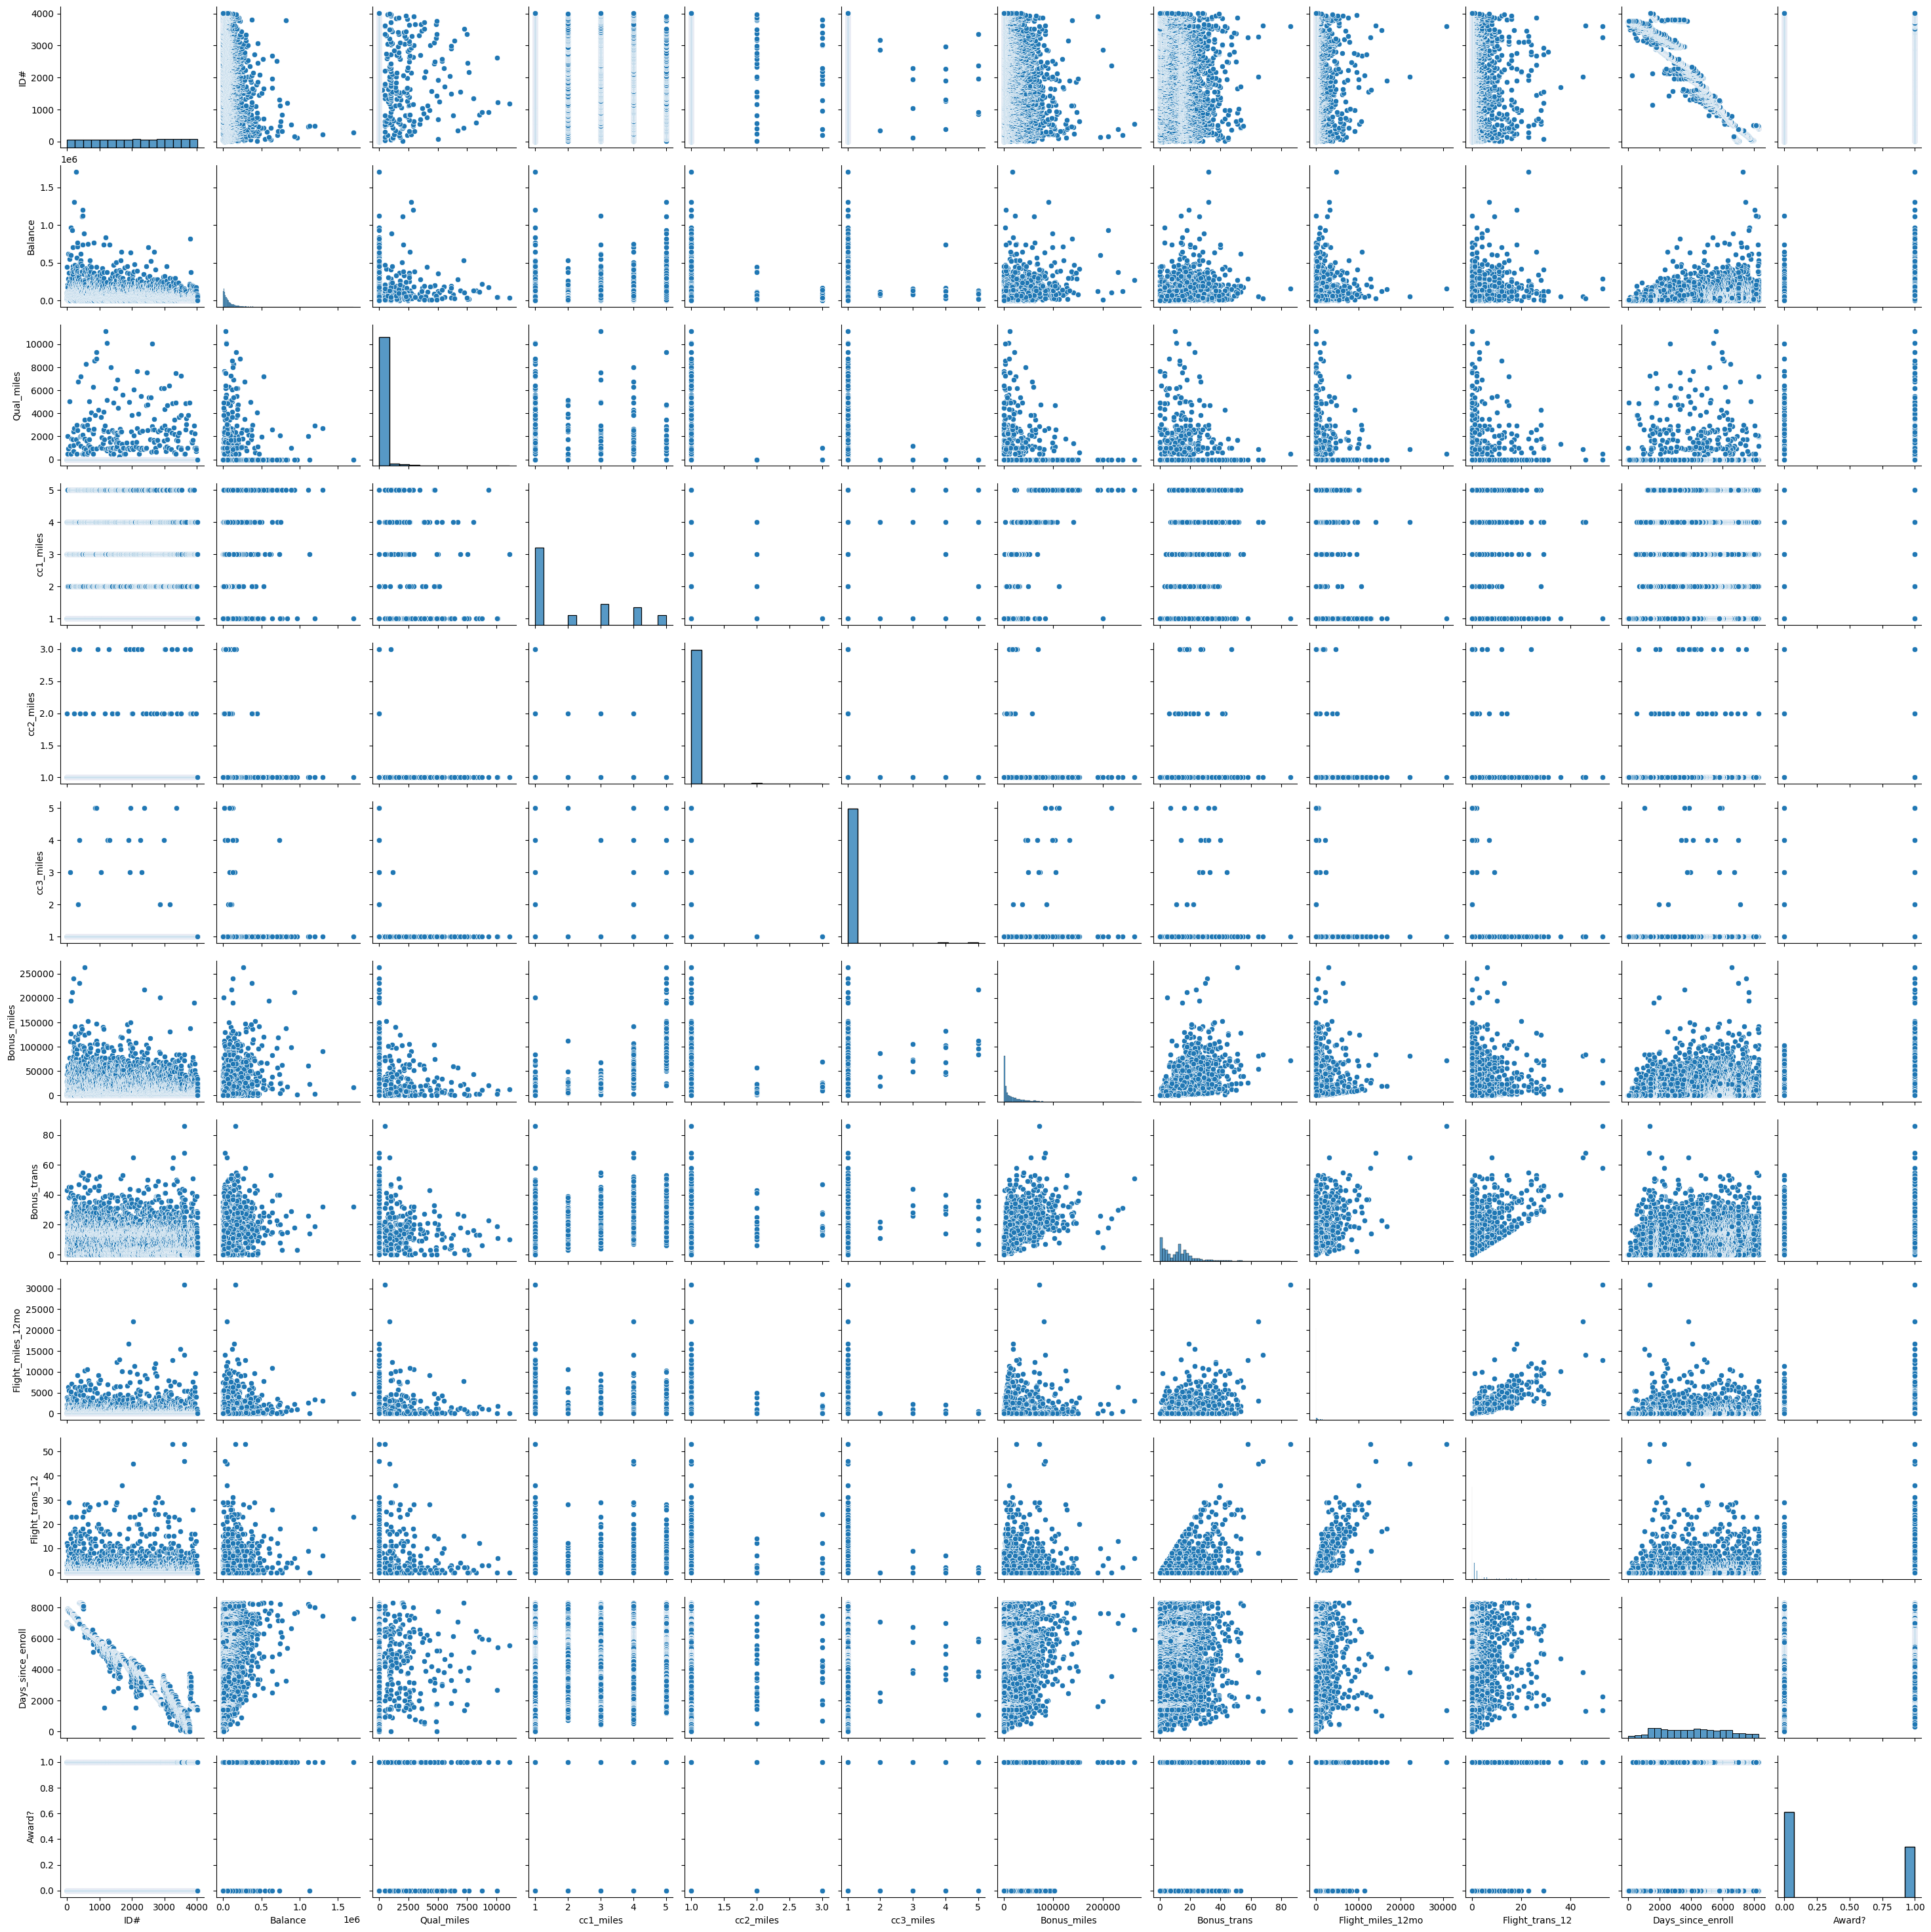

In [7]:
sns.pairplot(df)

Standarding the data

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale=pd.DataFrame(scaler.fit_transform(df))
scale

,0,1,2,3,4,5,6,7,8,9,10,11
0,-1.735125,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-1.734263,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-1.733402,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-1.732540,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,-1.731679,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,1.725097,-0.547079,-0.186299,-0.769578,-0.098242,-0.062767,-0.356960,-0.791649,-0.185750,-0.098503,-1.315120,1.303918
3995,1.725958,-0.091465,-0.186299,-0.769578,-0.098242,-0.062767,-0.669367,-0.687511,-0.328603,-0.362168,-1.318994,1.303918
3996,1.726820,-0.000043,-0.186299,0.683121,-0.098242,-0.062767,0.343804,-0.375096,-0.328603,-0.362168,-1.315604,1.303918
3997,1.727682,-0.185607,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,0.028531,-0.098503,-1.316088,-0.766919


Hierarchical Clustring

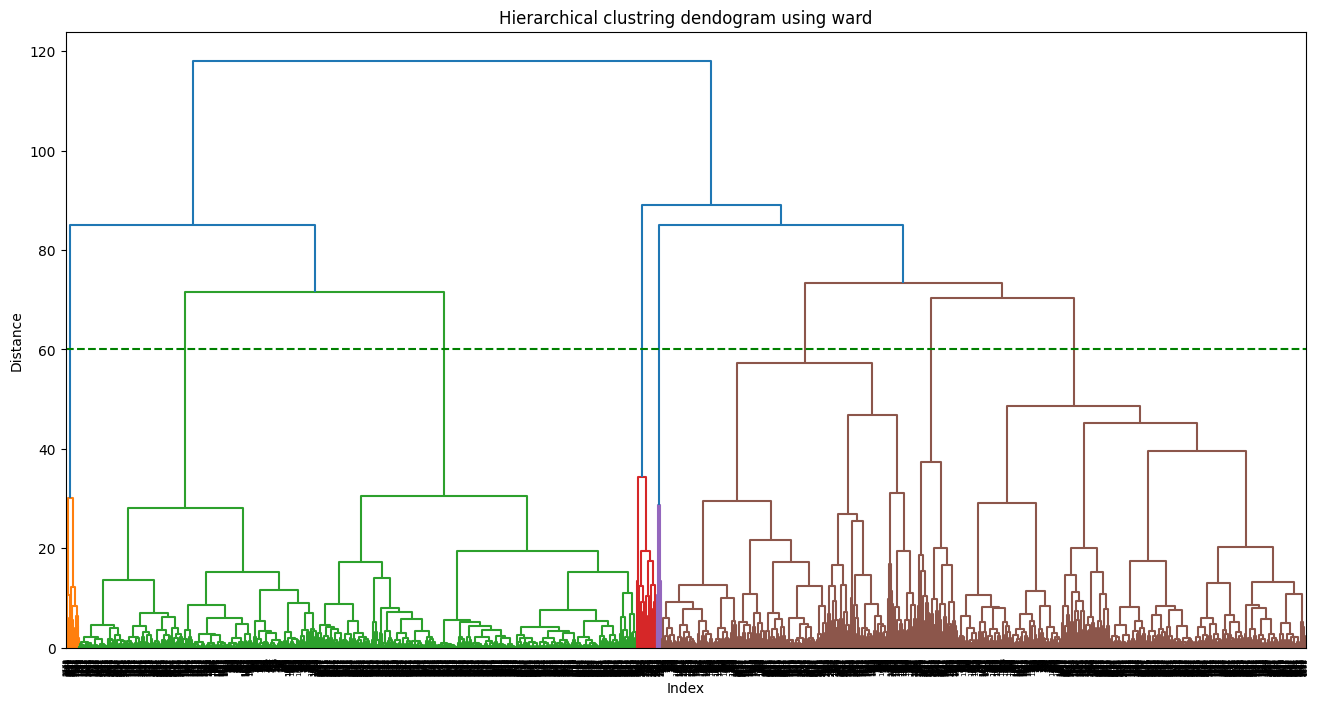

In [9]:
from scipy.cluster.hierarchy import linkage
import scipy.cluster.hierarchy as sch

s=linkage(scale,method='ward',metric='euclidean')
plt.figure(figsize=(16,8))
plt.title("Hierarchical clustring dendogram using ward")
plt.xlabel('Index')
plt.ylabel('Distance')
sch.dendrogram(s)
plt.axhline(y=60, linestyle='--' ,color='Green')
plt.show()

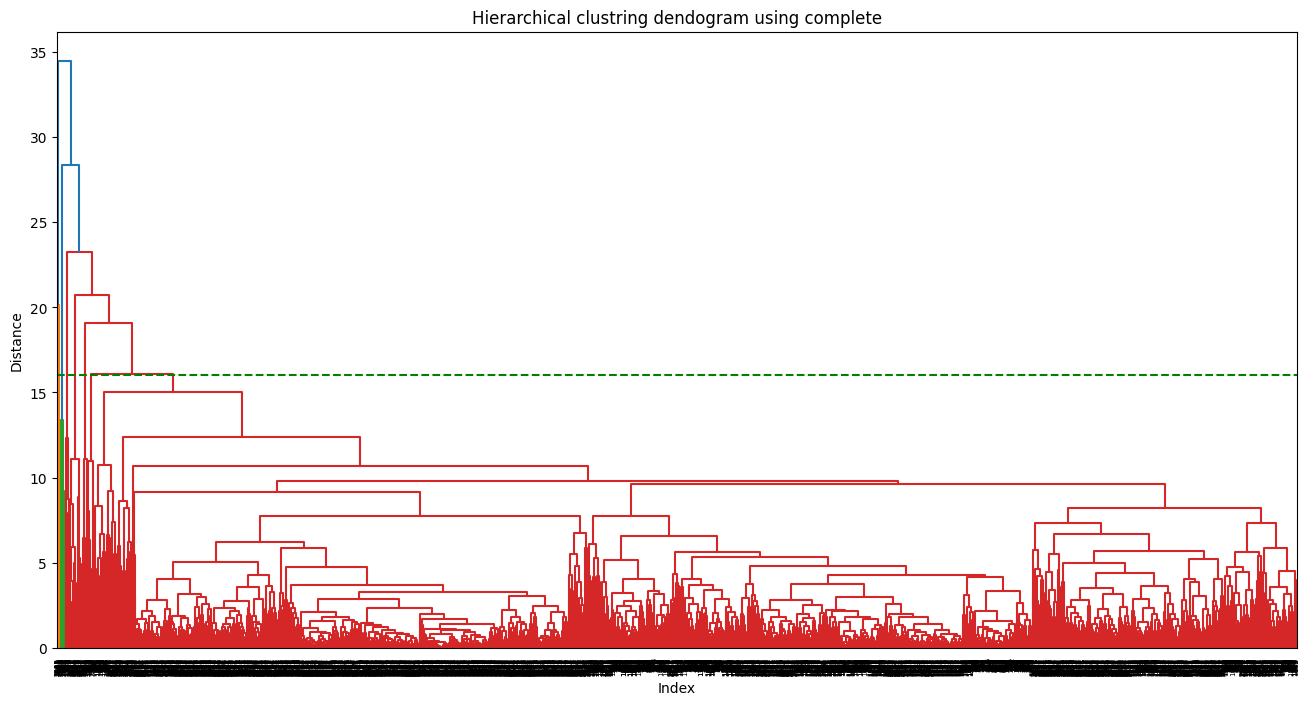

In [10]:
s=linkage(scale,method='complete',metric='euclidean')
plt.figure(figsize=(16,8))
plt.title('Hierarchical clustring dendogram using complete')
plt.xlabel('Index')
plt.ylabel('Distance')
sch.dendrogram(s)
plt.axhline(y=16,linestyle='--',color='Green')
plt.show()

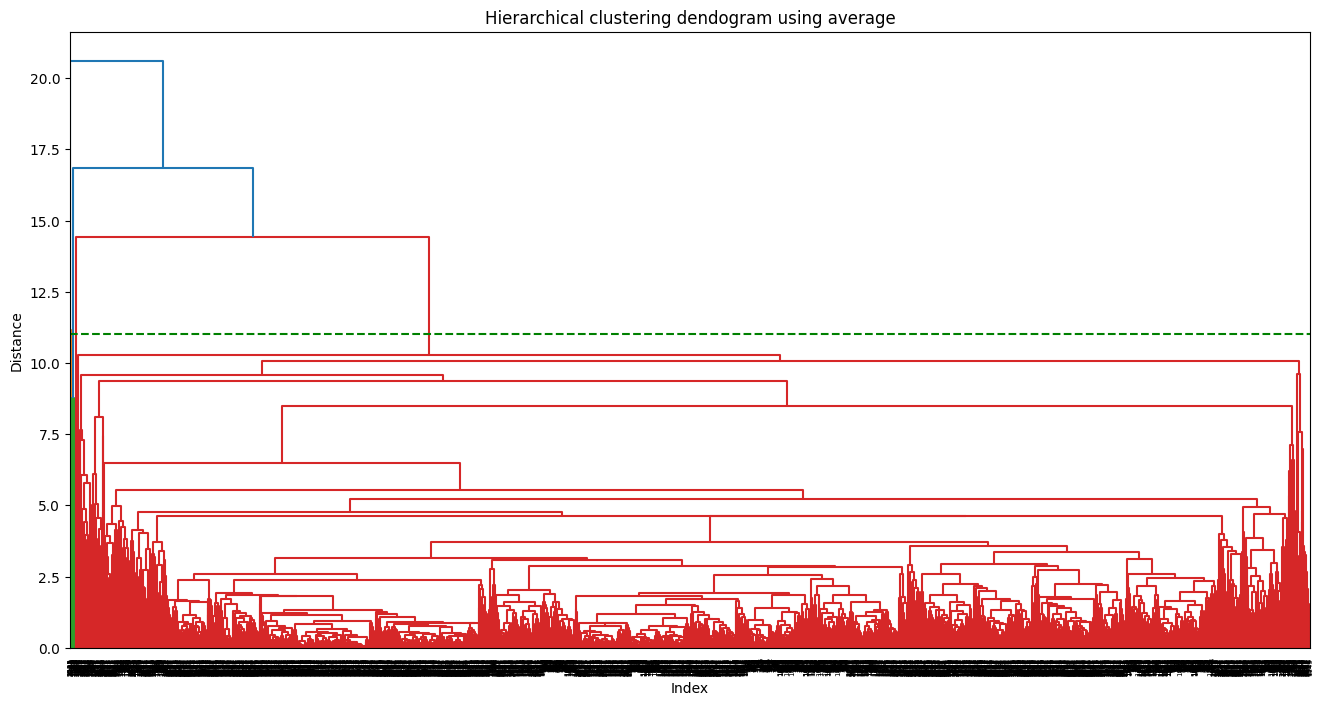

In [11]:
s=linkage(scale,method='average',metric='euclidean')
plt.figure(figsize=(16,8))
plt.title("Hierarchical clustering dendogram using average")
plt.xlabel("Index")
plt.ylabel('Distance')
sch.dendrogram(s)
plt.axhline(y = 11, linestyle = '--', color = 'Green')
plt.show()

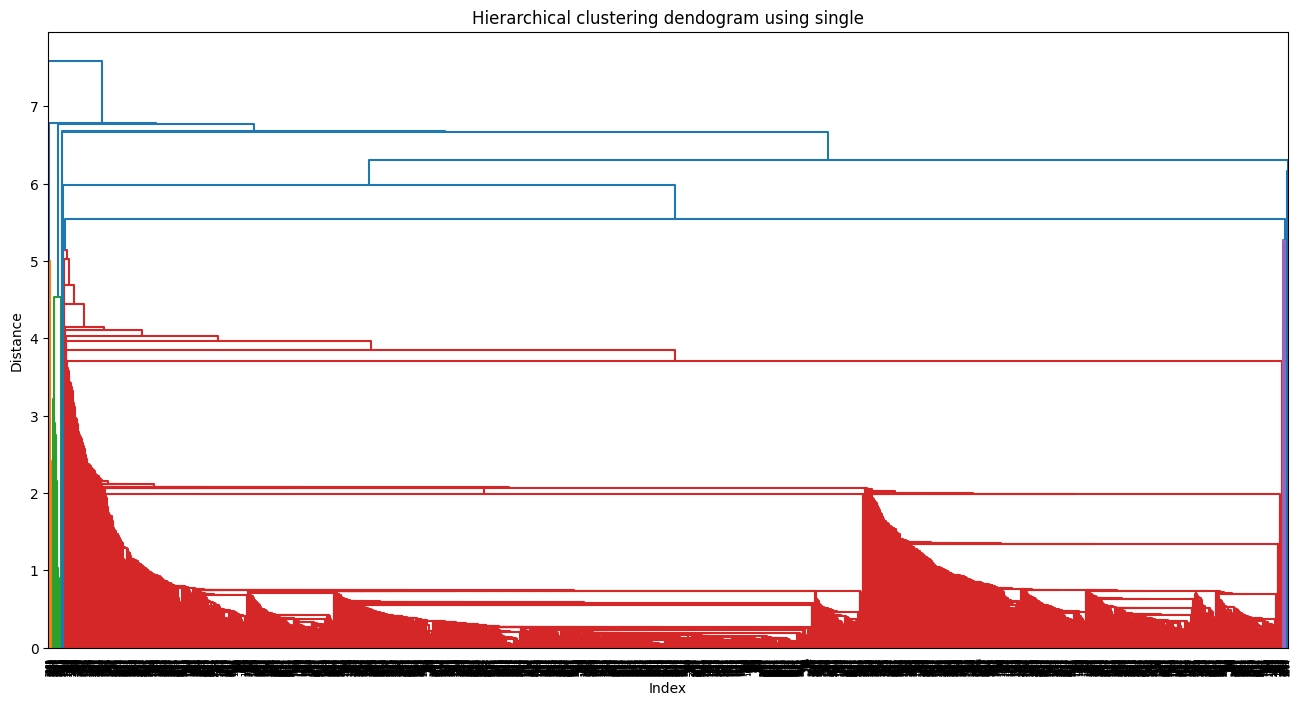

In [12]:
s=linkage(scale,method='single',metric='euclidean')
plt.figure(figsize=(16,8))
plt.title("Hierarchical clustering dendogram using single")
plt.xlabel("Index")
plt.ylabel('Distance')
sch.dendrogram(s)
plt.axhline(y = 60, linestyle = '--', color = 'Green')
plt.show()

Agglomerative Clustering

In [13]:
from sklearn.cluster import AgglomerativeClustering
ac=AgglomerativeClustering(n_clusters=11)
y_pred=ac.fit_predict(scale)
df['cluster']=y_pred
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,6
1,2,19244,0,1,1,1,215,2,0,0,6968,0,6
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,6
3,4,14776,0,1,1,1,500,1,0,0,6952,0,6
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0,3


Counting the clustering values

In [14]:
count=df['cluster'].value_counts()
count

cluster
3     1030
0      785
6      770
8      534
4      338
10     194
1      130
5       94
2       63
7       43
9       18
Name: count, dtype: int64

In [15]:
df.groupby(df['cluster']).mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
cluster,,,,,,,,,,,,
0,2464.563057,59643.095541,45.405096,2.217834,1.000000,1.000000,17607.352866,12.690446,751.713376,2.059873,3362.612739,0.931210
1,1888.546154,107600.192308,3533.292308,2.115385,1.000000,1.000000,20765.630769,12.176923,637.538462,2.038462,4335.830769,0.607692
2,1752.952381,160067.206349,573.587302,2.507937,1.000000,1.000000,42723.841270,34.142857,8148.619048,22.444444,4527.253968,0.873016
3,3234.521359,35722.737864,14.189320,1.269903,1.000000,1.000000,4678.673786,6.756311,106.763107,0.366990,1939.283495,0.000000
4,670.289941,64606.890533,12.109467,2.431953,1.000000,1.000000,19269.754438,13.766272,252.733728,0.766272,6492.875740,1.000000
5,864.851064,476949.680851,124.436170,3.053191,1.000000,1.000000,39201.404255,15.436170,717.074468,2.595745,6254.765957,0.744681
6,1257.824675,41562.179221,3.067532,1.068831,1.000000,1.000000,2556.364935,5.545455,123.045455,0.406494,5423.614286,0.000000
7,2269.372093,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349
8,1457.554307,107633.069288,5.610487,3.378277,1.000000,1.000000,28892.870787,17.086142,142.402622,0.441948,5097.876404,0.000000


visualizating cluster by using scatter plot

<Axes: xlabel='Qual_miles', ylabel='Balance'>

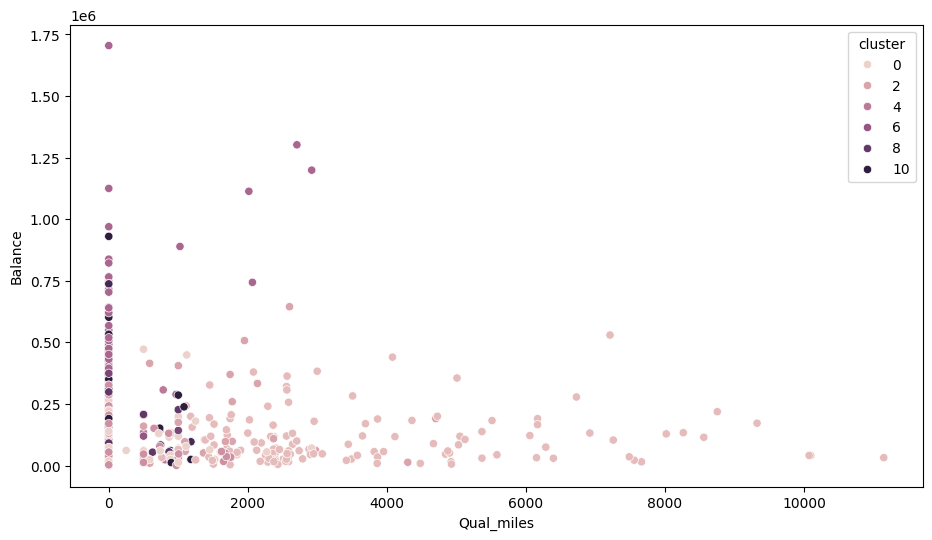

In [16]:
plt.figure(figsize=(11,6))
sns.scatterplot(x='Qual_miles',y='Balance',hue='cluster',data=df)

K-mean clustring

In [17]:
scale.columns=df.drop(columns='cluster').columns
scale

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.735125,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-1.734263,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-1.733402,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-1.732540,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,-1.731679,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,1.725097,-0.547079,-0.186299,-0.769578,-0.098242,-0.062767,-0.356960,-0.791649,-0.185750,-0.098503,-1.315120,1.303918
3995,1.725958,-0.091465,-0.186299,-0.769578,-0.098242,-0.062767,-0.669367,-0.687511,-0.328603,-0.362168,-1.318994,1.303918
3996,1.726820,-0.000043,-0.186299,0.683121,-0.098242,-0.062767,0.343804,-0.375096,-0.328603,-0.362168,-1.315604,1.303918
3997,1.727682,-0.185607,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,0.028531,-0.098503,-1.316088,-0.766919


Visualization the data

Text(0, 0.5, 'Balance')

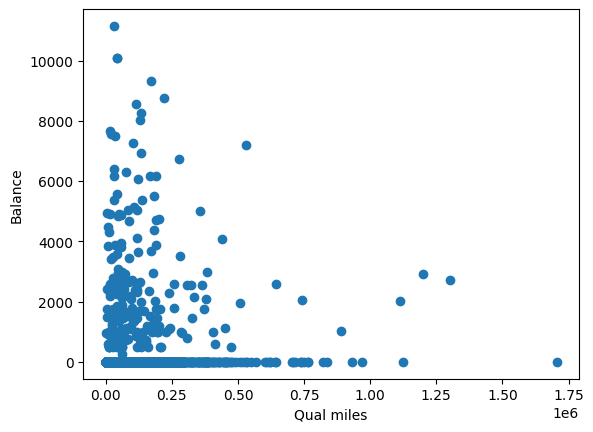

In [18]:
plt.scatter(df['Balance'],df['Qual_miles'])
plt.xlabel('Qual miles')
plt.ylabel('Balance')

Kmean Clustring

In [19]:
from sklearn.cluster import KMeans
kmean=KMeans()
kmean_pred=kmean.fit_predict(scale)
kmean_pred

array([2, 2, 2, ..., 0, 5, 5], dtype=int32)

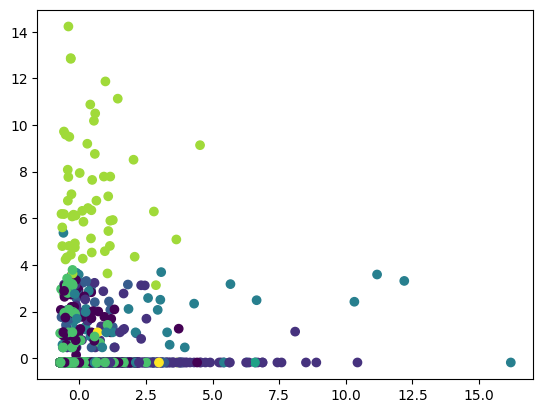

In [20]:
plt.scatter(scale['Balance'],scale['Qual_miles'],c=kmean_pred,cmap='viridis')

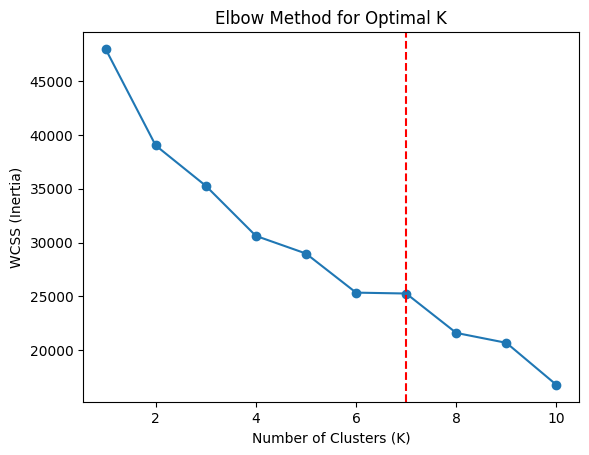

In [21]:
wcss = [KMeans(n_clusters=i).fit(scale).inertia_ for i in range(1, 11)]

plt.plot(range(1, 11), wcss, marker='o')
plt.axvline(x=7, linestyle='--', color='red')  
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.show()


DBSCAN


In [22]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=1.50,min_samples=7)
db_pred=dbscan.fit_predict(scale)
db_pred

array([0, 0, 0, ..., 1, 0, 0])

In [23]:
db=dbscan.labels_
db

array([0, 0, 0, ..., 1, 0, 0])

Silhouette score

In [24]:
from sklearn.metrics import silhouette_score
silhouette_score(scale,db)

np.float64(0.2122342471141035)